Say you've been iterating on a prompt for a **support ticket classifier**: a backend system that routes incoming customer requests into one of four queues: `BILLING`, `TECHNICAL`, `ACCOUNT`, or `GENERAL`. This system needs to run fast, so you're hoping to run it on a very small local model, `gemma3:1b`. 

You've tried eight different prompt template variations: a zero-shot baseline, a role-framed variant, one with explicit category definitions, two few-shot variants (1-example and 3-example), a chain-of-thought approach, one that returns JSON, and one with negative framing ("do *not* confuse BILLING with ACCOUNT").

After running the eval on 40 labeled tickets with a local Ollama model (`gemma3:1b`), you compute mean accuracy per prompt in the hopes of finding the "winner":

P0_baseline                   45.0%
P1_role                       42.5%
P2_definitions                45.0%
P3_few_shot_1                 62.5%
P4_few_shot_3                 65.0%
P5_chain_of_thought           55.0%
P6_json_output                67.5%
P7_negative_framing           37.5%


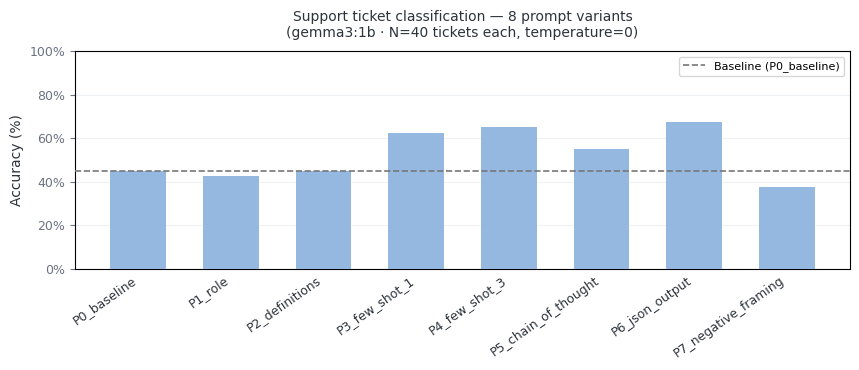

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import promptstats as pstats
pstats.set_alpha_ci(0.05)  # Set the default alpha for CIs to 0.05 for this example

# Load eval results.
# Columns: prompt_id, input_id, ticket, category, output, predicted, correct
df = pd.read_csv("support_ticket_eval.csv")

# The CSV stores expected/predicted pairs (not precomputed scores),
# so we compute per-prompt accuracy manually from `correct`.
PROMPTS = df["prompt_id"].dropna().drop_duplicates().tolist()

# Mean accuracy per prompt
scores_1run = {
    p: df[df["prompt_id"] == p]["correct"].tolist()
    for p in PROMPTS
}
summary = {p: round(sum(v) / len(v) * 100, 1) for p, v in scores_1run.items()}
for p, acc in summary.items():
    print(f"{p:<28}  {acc:.1f}%")

pstats.plot_accuracy_bar(
    scores_1run,
    baseline="P0_baseline",
    title=(
        "Support ticket classification — 8 prompt variants\n"
        "(gemma3:1b · N=40 tickets each, temperature=0)"
    ),
)
plt.show()

## The multiple comparisons problem

The scoreboard looks decisive. `P6_json_output` leads at **67.5%**, `P7_negative_framing` tanks at **37.5%** — a 30-point spread. Few-shot examples help (P3: 62.5%, P4: 65%). Chain-of-thought lands in the middle at 55%. And just adding a role persona alone (`P1_role`) somehow *hurt* by 2.5 points.

But before declaring a winner, there's a problem: you just ran **8 prompt variants on the same 40 tickets.** Every additional comparison you add inflates your risk of a false positive — of calling something "the winner" when it's just lucky sampling noise. With 8 prompts and 28 possible pairwise comparisons, the chance of at least one spurious "significant" result at α = 0.05 is roughly:

```
P(≥1 false positive) = 1 − (1 − 0.05)^28 ≈ 76%
```

Even in the simpler framing of comparing each of 7 variants to a single baseline (7 tests):

```
P(≥1 false positive) = 1 − (1 − 0.05)^7 ≈ 30%
```

To see how this plays out in practice, let's run a simulation. We'll ask: if all 8 prompts were *equally good* — same true accuracy, just different samples — how large a spread between the best and worst would we typically see on 40 tickets?

In [2]:
rng_sim = np.random.default_rng(0)

N_PROMPTS = 8
N_TICKETS = 40
N_SIM = 10_000
TRUE_RATE = 0.55  # all 8 prompts equally good

# For each of 10,000 simulated eval runs, draw binary scores for all 8 prompts
scores_sim = rng_sim.binomial(1, TRUE_RATE, size=(N_SIM, N_PROMPTS, N_TICKETS))
means_sim = scores_sim.mean(axis=2)  # (N_SIM, N_PROMPTS)

# Spread between the best and worst prompt in each run
spreads = means_sim.max(axis=1) - means_sim.min(axis=1)

p50, p90, p95 = np.percentile(spreads, [50, 90, 95])
our_spread = 0.675 - 0.375  # P6_json_output vs P7_negative_framing

print(f"Simulation: {N_PROMPTS} equally-good prompts · true rate = {TRUE_RATE:.0%} · N = {N_TICKETS} tickets")
print(f"Results across {N_SIM:,} simulated eval runs:")
print()
print(f"  Typical (median) best-vs-worst spread:  {p50:.1%}")
print(f"  Spread exceeded in 10% of runs:         {p90:.1%}")
print(f"  Spread exceeded in  5% of runs:         {p95:.1%}")
print()
print(f"  Our observed best-vs-worst spread:      {our_spread:.1%}  (P6 vs P7)")
p_as_extreme = (spreads >= our_spread).mean()
print(f"  P(spread ≥ observed | all equal):       {p_as_extreme:.1%}")
print()
# Rank-winner inflation
top_means = means_sim.max(axis=1)
print(f"  Expected sample accuracy of the naive 'winner':  {top_means.mean():.1%}")
print(f"  True accuracy of every prompt:                   {TRUE_RATE:.1%}")
print(f"  Winner-inflation from always picking the top:   +{top_means.mean() - TRUE_RATE:.1%}")

Simulation: 8 equally-good prompts · true rate = 55% · N = 40 tickets
Results across 10,000 simulated eval runs:

  Typical (median) best-vs-worst spread:  22.5%
  Spread exceeded in 10% of runs:         30.0%
  Spread exceeded in  5% of runs:         32.5%

  Our observed best-vs-worst spread:      30.0%  (P6 vs P7)
  P(spread ≥ observed | all equal):       11.8%

  Expected sample accuracy of the naive 'winner':  66.1%
  True accuracy of every prompt:                   55.0%
  Winner-inflation from always picking the top:   +11.1%


With N=40, the typical best-vs-worst spread across 8 equally-good prompts is already **~22 percentage points** — just from sampling noise. Our observed 30-point spread is not dramatically unusual. And when you always pick the highest-scoring prompt, selection bias inflates its apparent accuracy by several points relative to its true performance.

## Correcting for multiple comparisons with Holm–Bonferroni

The standard fix is **Holm–Bonferroni correction** (usually just "Holm correction"). When you run _k_ hypothesis tests simultaneously, Holm correction adjusts each test's threshold to keep your *family-wise error rate* — the probability of making even one false discovery across all tests — bounded at α = 0.05.

It works by sorting your _k_ p-values from smallest to largest, then checking each one against a progressively relaxed threshold: α/k, α/(k−1), α/(k−2), …, α/1. The first p-value that fails its threshold stops the procedure. This is strictly more powerful than plain Bonferroni (which applies α/k to every test), while providing the same strong error control.

`promptstats` applies Holm correction automatically when you pass `correction="holm"` to `compare_prompts`. Since our scores are binary (pass/fail), it selects the `bayes_binary` method automatically — which our simulation studies show is better calibrated than a plain bootstrap at small sample sizes.

> **Holm vs. FDR?** The alternative, `correction="fdr_bh"` (Benjamini–Hochberg), controls the *false discovery rate* rather than the *family-wise* error rate. FDR is less conservative and favored when you have many comparisons and can tolerate a small fraction of false positives. Holm is the right choice here: we're making a deployment decision, and we want to be sure before calling any prompt the winner.

Let's run the full analysis:

  Prompt                   Mean  95% CI                  Status
  -----------------------------------------------------------------
  P0_baseline            45.0%  [30.7%, 60.2%]          in contention
  P1_role                42.5%  [28.5%, 57.8%]          outperformed
  P2_definitions         45.0%  [30.7%, 60.2%]          in contention
  P3_few_shot_1          62.5%  [47.0%, 75.8%]          in contention
  P4_few_shot_3          65.0%  [49.5%, 77.9%]          in contention
  P5_chain_of_thought    55.0%  [39.8%, 69.3%]          in contention
  P6_json_output         67.5%  [52.0%, 79.9%]          in contention
  P7_negative_framing    37.5%  [24.2%, 53.0%]          outperformed


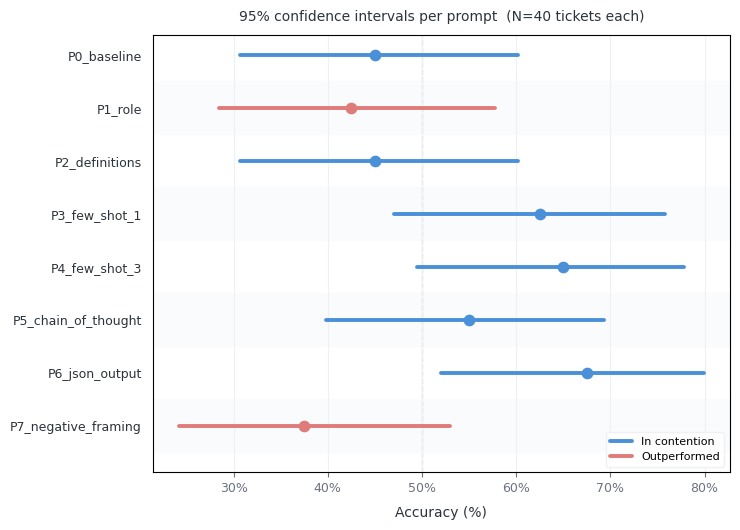

In [3]:
# One score array per prompt (40 binary values each)
scores = {
    p: df[df["prompt_id"] == p]["correct"].tolist()
    for p in PROMPTS
}

# compare_prompts runs all pairwise comparisons with Holm correction.
report = pstats.compare_prompts(
    scores,
    correction="holm",
    rng=np.random.default_rng(42),
    # If we were using a bootstrap method, we could control for multiple comparisons in the CIs too:
    # simultaneous_ci=True,  # Correct pairwise CIs for multiple comparisons
)

report.print_ci_table()

pstats.plot_ci_forest(
    report,
    title="95% confidence intervals per prompt  (N=40 tickets each)",
    sort_by="input_order"
)
plt.show()

In [4]:
report.summary()

 PROMPTS COMPARISON 
8 prompts | 40 inputs | method=bayes_binary | correction=holm | CI=95%

--- Pairwise Comparisons (lowest p-value first) ---
  Friedman omnibus: χ²(7) = 31.634, p = 4.749e-05***
  axis: [-0.864, +0.864]  (· ±1σ, ─ CI, ● mean, │ zero)
  Pair                             Interval Plot                                 Mean    CI Low   CI High     r_rb   p (boot)   p (wsr)   p (nem)
  P1_role vs P6_json_output            ······────●───··│····                  -0.2500   -0.4150   -0.1146   -1.000    0.0168*  0.04383*    0.6024
  P6_json_output vs P7_negative_f…               ······│··────●────·········  +0.3000   +0.1173   +0.4658    0.750    0.0486*   0.07289    0.3571
  P2_definitions vs P6_json_output      ······────●───·│·····                 -0.2250   -0.3923   -0.0898   -1.000      0.052   0.07289    0.7239
  P2_definitions vs P4_few_shot_3        ······───●───·│·····                 -0.2000   -0.3611   -0.0782   -1.000      0.065    0.1127    0.8284
  P4_few_shot_3 

## Reading the results

The executive summary groups prompts into tiers based on which pairwise differences survive Holm correction.

**Group #1 (tied at the top):** `P6_json_output`, `P4_few_shot_3`, `P3_few_shot_1`, `P5_chain_of_thought`, `P0_baseline`, `P2_definitions`. These six prompts — spanning raw accuracies from **45.0% to 67.5%** — are statistically *indistinguishable* from one another at N=40. The confidence intervals are ~30 percentage points wide and overlap heavily. After Holm correction, no pairwise difference within this group survives.

**Group #2 (confirmed underperformers):** `P1_role` (42.5%) and `P7_negative_framing` (37.5%) are significantly *worse* than the top tier. This is the most actionable finding: two common prompt patterns genuinely hurt performance on this model. A role-only persona with no other guidance seems to confuse `gemma3:1b`, and negative/contrastive framing ("do NOT confuse BILLING with ACCOUNT") backfires badly.

**What happened to the "winner"?** `P6_json_output` at 67.5% looked like a clear leader. But its 95% CI is `[52.0%, 79.9%]`, and `P0_baseline`'s is `[30.7%, 60.2%]` — these intervals overlap by about 8 percentage points. With N=40, you simply don't have the resolution to confirm whether the 22-point gap between them is real. To reliably detect a 20-point gap at 80% power, you'd need roughly **N=80–100 tickets**. To detect a 10-point gap, closer to **N=250+**.

The raw bar chart told a story. A lot of it was noise.

> **Honest reporting template.** *"Among the six top-tier prompts, differences are within sampling noise at N=40. `P6_json_output` has the highest point estimate (67.5%) and is a reasonable provisional choice, but the margin over baseline is not statistically confirmed. `P1_role` and `P7_negative_framing` are confirmed underperformers and should be dropped. Re-run the eval with ~150 tickets to resolve the top-tier ranking."*

## Expanding the eval set — and adding multiple runs

Our CIs were wide for two reasons: only 40 tickets, and possible run-to-run stochasticity at
temperature > 0. We tackle both at once.

We rebuilt the eval set with **120 tickets** (30 per category): the original 10 clear-cut
examples per category, 10 harder **boundary cases** that straddle two categories, and 10
**adversarial cases** that use surface framing designed to mislead simpler prompts. For example:

| Ticket | Looks like | Actually |
|--------|-----------|---------|
| "The feature I upgraded for last month never worked — I'd like a credit." | TECHNICAL | **BILLING** |
| "2FA codes never arrive by SMS, no matter how many retries." | ACCOUNT | **TECHNICAL** |
| "What's the difference between Owner, Admin, and Member roles?" | ACCOUNT | **GENERAL** |
| "After rotating my API key, all production integrations broke." | ACCOUNT | **TECHNICAL** |
| "You charged me twice and your team keeps closing my ticket without fixing it." | BILLING | **GENERAL** |

We also ran each (prompt, ticket) pair **5 times** at temperature=1.0. Passing a `(M=120, R=5)`
score matrix per prompt activates the *nested bootstrap* — resampling both tickets and runs within
each ticket — so CIs reflect both sources of variance.

The question: **which lever actually moved the needle?**

Let's start by checking run-to-run consistency on the expanded set:

In [5]:
# Load the multi-run CSV (one row per prompt x ticket x run)
df_mr = pd.read_csv("support_ticket_eval_multirun.csv")

# Accuracy per (prompt, run) — if scores are flat across runs,
# run-to-run variance is low and extra runs won't tighten CIs much
run_acc = (
    df_mr.groupby(["prompt_id", "run_idx"])["correct"]
    .mean()
    .unstack("run_idx")
    .loc[PROMPTS]
)
run_acc.columns = [f"run {c}" for c in run_acc.columns]
run_acc["mean"] = run_acc.mean(axis=1)
run_acc["std"]  = run_acc.iloc[:, :5].std(axis=1)

print("Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):")
print(run_acc.to_string(float_format="{:.1%}".format))

Per-run accuracy (temperature=1.0, 5 runs x 120 tickets):
                     run 1  run 2  run 3  run 4  run 5  mean  std
prompt_id                                                        
P0_baseline          42.5%  45.8%  44.2%  44.2%  44.2% 44.2% 1.2%
P1_role              40.8%  40.0%  44.2%  40.8%  42.5% 41.7% 1.7%
P2_definitions       38.3%  38.3%  38.3%  39.2%  38.3% 38.5% 0.4%
P3_few_shot_1        51.7%  51.7%  52.5%  52.5%  51.7% 52.0% 0.5%
P4_few_shot_3        54.2%  54.2%  52.5%  52.5%  52.5% 53.2% 0.9%
P5_chain_of_thought  48.3%  49.2%  44.2%  46.7%  47.5% 47.2% 1.9%
P6_json_output       55.8%  55.8%  57.5%  55.8%  56.7% 56.3% 0.7%
P7_negative_framing  34.2%  30.8%  34.2%  32.5%  31.7% 32.7% 1.5%


Even across 120 examples with harder cases included, the model is highly consistent across runs.
`P2_definitions` and `P6_json_output` again have near-zero run-to-run variance. The highest
standard deviation is about 2% (`P5_chain_of_thought`), and most prompts are well below that.

Notice that the harder examples are doing work here: the rankings are spreading out meaningfully.
`P6_json_output` (56.3%) is pulling ahead of `P2_definitions` (38.5%) by a much wider margin
than the original 40-ticket eval suggested. The adversarial examples in particular are exposing
that structured prompts (few-shot, JSON output) handle ambiguity far better than
definition-heavy or negatively-framed ones.

Let's run the statistics and see if we finally have enough data to separate the pack:

Prompt                        40T · 1R    120T · 1R    120T · 5R    Δ tickets     Δ runs
----------------------------------------------------------------------------------------
P0_baseline                       29.5%       17.5%       17.0%       -12.0%    -0.5%
P1_role                           29.3%       17.5%       16.7%       -11.8%    -0.8%
P2_definitions                    29.5%       16.7%       17.5%       -12.8%    +0.8%
P3_few_shot_1                     28.7%       18.3%       18.0%       -10.4%    -0.3%
P4_few_shot_3                     28.4%       17.5%       17.5%       -10.9%    +0.0%
P5_chain_of_thought               29.5%       18.3%       17.3%       -11.1%    -1.0%
P6_json_output                    27.9%       18.3%       17.7%        -9.6%    -0.7%
P7_negative_framing               28.7%       16.7%       16.5%       -12.1%    -0.2%


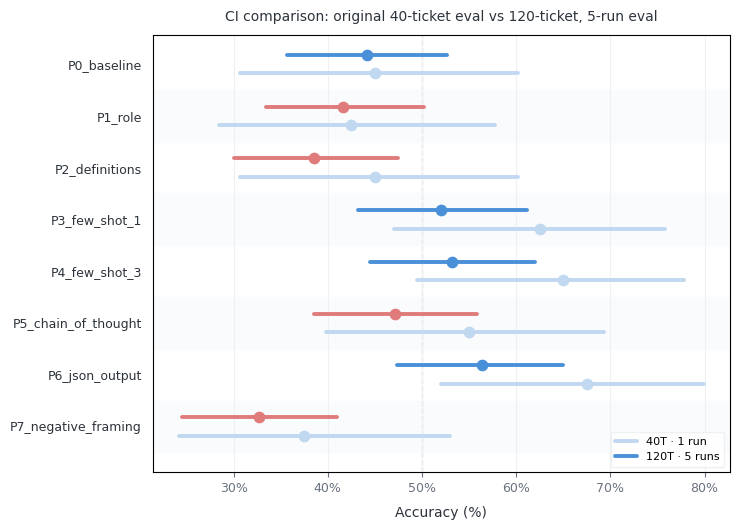

In [6]:
# Reshape to {prompt: array of shape (120 tickets, 5 runs)}
scores_mr = {
    p: (
        df_mr[df_mr["prompt_id"] == p]
        .pivot(index="input_id", columns="run_idx", values="correct")
        .values.tolist()
    )
    for p in PROMPTS
}
report_mr = pstats.compare_prompts(
    scores_mr,
    correction="holm",
    rng=np.random.default_rng(42),
)

# 120-ticket single-run report (run 1 only) for a clean three-way comparison
df_1run = df_mr[df_mr["run_idx"] == 1]
scores_1run = {p: df_1run[df_1run["prompt_id"] == p]["correct"].tolist() for p in PROMPTS}
report_1run = pstats.compare_prompts(
    scores_1run,
    correction="holm",
    rng=np.random.default_rng(42),
)

# Three-way CI width table: original 40T/1R  ->  120T/1R  ->  120T/5R
header = f"{'Prompt':<28}  {'40T · 1R':<10}  {'120T · 1R':<11}  {'120T · 5R':<11}  {'Δ tickets':<12}  {'Δ runs'}"
print(header)
print("-" * len(header))
for p in PROMPTS:
    s0 = report.model_stats[p]        # original 40-ticket eval (cell 5)
    s1 = report_1run.model_stats[p]
    s5 = report_mr.model_stats[p]
    w0 = s0.ci_high - s0.ci_low
    w1 = s1.ci_high - s1.ci_low
    w5 = s5.ci_high - s5.ci_low
    print(f"{p:<28}  {w0:>9.1%}  {w1:>10.1%}  {w5:>10.1%}  {w1 - w0:>+11.1%}  {w5 - w1:>+7.1%}")

# Forest plot: 40T single-run (light) vs 120T 5-run (coloured by tier)
pstats.plot_ci_forest(
    report_mr,
    compare_to=report,
    report_label="120T · 5 runs",
    compare_label="40T · 1 run",
    title="CI comparison: original 40-ticket eval vs 120-ticket, 5-run eval",
    sort_by="input_order"
)
plt.show()

Notice how much tighter the dark intervals are in the plot: those are the **120-ticket, 5-run** CIs, compared against the lighter **original 40-ticket** CIs for the same prompts.

The main effect is from more (and harder) eval items. Extra runs help a little (if we plotted this, we would see), but the CI tightening here is dominated by expanding the eval set.

Also notice that our original CI estimates for `P6_json_output`, `P3_few_shot_1`, etc., were over-confident. Or were they? 

When we expanded our test set with harder examples, performance flattened a bit across the board. Still, though, the JSON output prompt seems to lead. Let's output a full summary to check which are the likely winners.

In [7]:
report_mr.full_summary()

Shape: BenchmarkShape(models=1, prompts=8, input_vars=1, evaluators=1, runs=5)
Templates: 8 | Inputs: 120 | Runs: 5

--- Robustness ---
                         mean  median       std        cv  iqr  cvar_10  p10  p25  p50  p75  p90
template                                                                                        
P0_baseline          0.441667     0.2  0.476610  1.079116  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P1_role              0.416667     0.0  0.463515  1.112435  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P2_definitions       0.385000     0.0  0.487258  1.265605  1.0      0.0  0.0  0.0  0.0  1.0  1.0
P3_few_shot_1        0.520000     1.0  0.499681  0.960924  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P4_few_shot_3        0.531667     1.0  0.492291  0.925939  1.0      0.0  0.0  0.0  1.0  1.0  1.0
P5_chain_of_thought  0.471667     0.2  0.478651  1.014807  1.0      0.0  0.0  0.0  0.2  1.0  1.0
P6_json_output       0.563333     1.0  0.493305  0.875690  1.0      0.0  0.0  0.0  1.0  

This output a lot of information, but the key thing we want to look at now is the Executive Summary. Based on tests of statistical significance, we estimate three "tiers" of prompts. This is just an estimate, but it does help us parse the outcomes and corresponds to the 95% CIs. The 95% CI for `P6_json_output`, for instance, doesn't overlap the last three prompts (P1, P2, P7)—meaning we might conclude, at this stage, that P6 is better than these. 

If this were a real scenario, at this stage, we might drop the worst-performing candidates P1, P2, and P7, and then proceed to mutate and improve the best-performing candidates. That's the idea at the heart of evolutionary algorithms like EvoPrompt and PromptBreeder. We might also add a reflection pass, where an LLM looks at the misclassifications, identifies common failure modes, and tries to add criteria to the prompts to avoid the problems that it observed. But that's for another set of investigations.

## Conclusion: What actually moved the needle

The three-way CI width table and the 40T-vs-120T·5R forest plot tell the same story:

* **Expanding the size of our eval led to a big improvement.** Going from an eval with N=40 samples to 120 samples (with harder examples) cut CI widths by roughly 10 percentage points each. The harder boundary and adversarial examples do double duty: they add statistical power *and* they stress-test prompts in the regime where differences actually show up.
* **Multiple runs weren't that informative here.** Perhaps because `gemma3:1b` is such a small model, or because classification tasks are simpler, there wasn't a lot of variation in outputs, even though temperature was set to 1.0. The extra runs trim about ~1 pp off most CIs — real, but small. The model remains highly stable run-to-run (std ≈ 0–2%), so ticket count is still the main bottleneck. 

At 120 tickets, ranking differences are much clearer than in the 40-ticket pass. The highest
point estimates are now concentrated among the structured prompting styles (JSON output and few-shot),
while definition-heavy and negative-framing variants lag.

A few patterns stand out about the winning prompts, versus the losers:

* **Structured outputs lead.** Forcing structured JSON (P6) or using worked examples (P3, P4)
  consistently beats free-text formulations on the harder cases.
* **Chain-of-thought is not a clear win here.** P5 does not show a reliable lift over simpler
  prompts on this small model.
* **Definitions and negative framing underperform.** These styles appear to over-anchor on surface
  wording and struggle on ambiguous/adversarial tickets.

> **Practical takeaway:** if your model is stable at your chosen temperature, spend most of your
> budget on expanding and hardening the eval set. In this workflow, more diverse tickets improve
> precision far more than extra repeat runs.